In [19]:
pip install wfdb

  Using cached wfdb-4.3.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pandas-2.3.0-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
Using cached wfdb-4.3.0-py3-none-any.whl (163 kB)
Using cached pandas-2.3.0-cp312-cp312-win_amd64.whl (11.0 MB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
  Attempting uninstall: aiohappyeyeballs
    Found existing installation: aiohappyeyeballs 2.4.0
    Uninstalling aiohappyeyeballs-2.4.0:
      Successfully uninstalled aiohappyeyeballs-2.4.0
  Attempting uninstall: yarl
    Found existing installation: yarl 1.11.0
    Uninstalling yarl-1.11.0:
      Successfully uninstalled yarl-1.11.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pa

In [20]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import ast
import os
## pip install wfdb as we are dealing with .dat files and not .npy files
import wfdb

In [ ]:
data_path = "C:\\Users\\Pranav Yeturu\\Desktop\\New folder\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
records_path = data_path + 'records500/'
df = pd.read_csv(data_path + '\\ptbxl_database.csv')
print(df[['filename_hr', 'scp_codes']].head())
## The relative file path (within records500/) to the high-resolution ECG signal (500 Hz) : filename_hr
## A dictionary of diagnostic codes (SCP = Standard Communications Protocol) and their weights (importance/confidence), per recording : scp_codes

                 filename_hr                                 scp_codes
0  records500/00000/00001_hr  {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
1  records500/00000/00002_hr              {'NORM': 80.0, 'SBRAD': 0.0}
2  records500/00000/00003_hr                {'NORM': 100.0, 'SR': 0.0}
3  records500/00000/00004_hr                {'NORM': 100.0, 'SR': 0.0}
4  records500/00000/00005_hr                {'NORM': 100.0, 'SR': 0.0}


In [22]:
# Filter to top diagnostic superclasses (optional)
if isinstance(df['scp_codes'].iloc[0], str):
    df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

df['diagnostic_superclass'] = df['scp_codes'].apply(lambda x: list(x.keys())[0] if x else None)

# Load a sample ECG signal
sample = df.iloc[0]
record_path = os.path.join(data_path, sample['filename_hr']) 

Signal shape: (5000, 12)


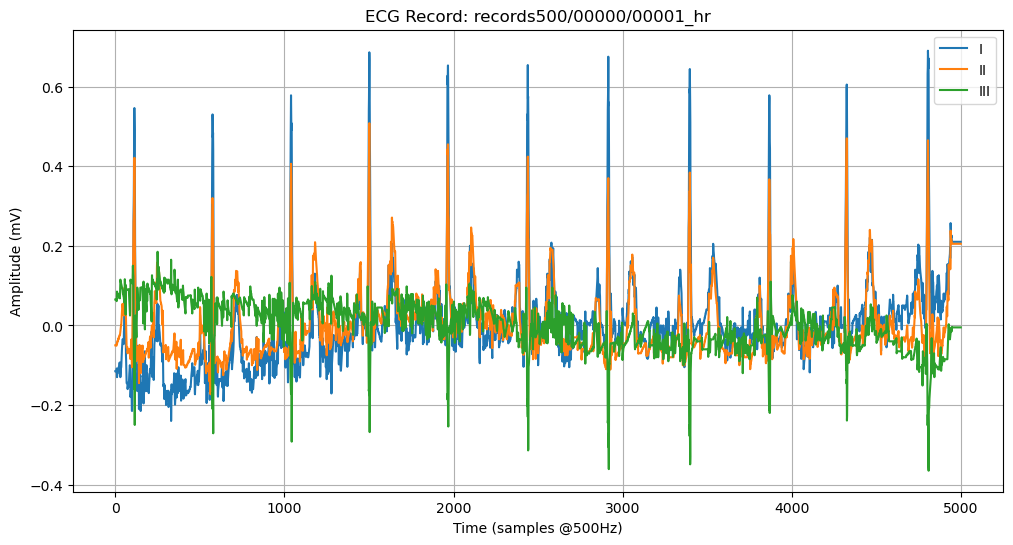

In [23]:
record = wfdb.rdrecord(record_path)

# Extract signal
signal = record.p_signal  # shape: (5000, 12)
print("Signal shape:", signal.shape)

# Plot first 3 leads
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(signal[:, i], label=record.sig_name[i])
plt.title(f"ECG Record: {sample['filename_hr']}")
plt.xlabel("Time (samples @500Hz)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)
plt.show()

Successfully loaded and visualized real ECG data from the PTB-XL dataset using the original .dat and .hea files with the wfdb library. 
The plot displays the first 3 leads (I, II, III) of a 12-lead ECG recording, captured over 10 seconds at a sampling rate of 500 Hz. 
The x-axis represents time in samples, while the y-axis shows electrical amplitude in millivolts (mV). 
Distinct, periodic R-peaks are visible in the waveform, especially in Lead II, indicating healthy ventricular contractions. Each lead offers a different electrical view of heart activity, and their patterns help in detecting arrhythmias or other cardiac conditions. 

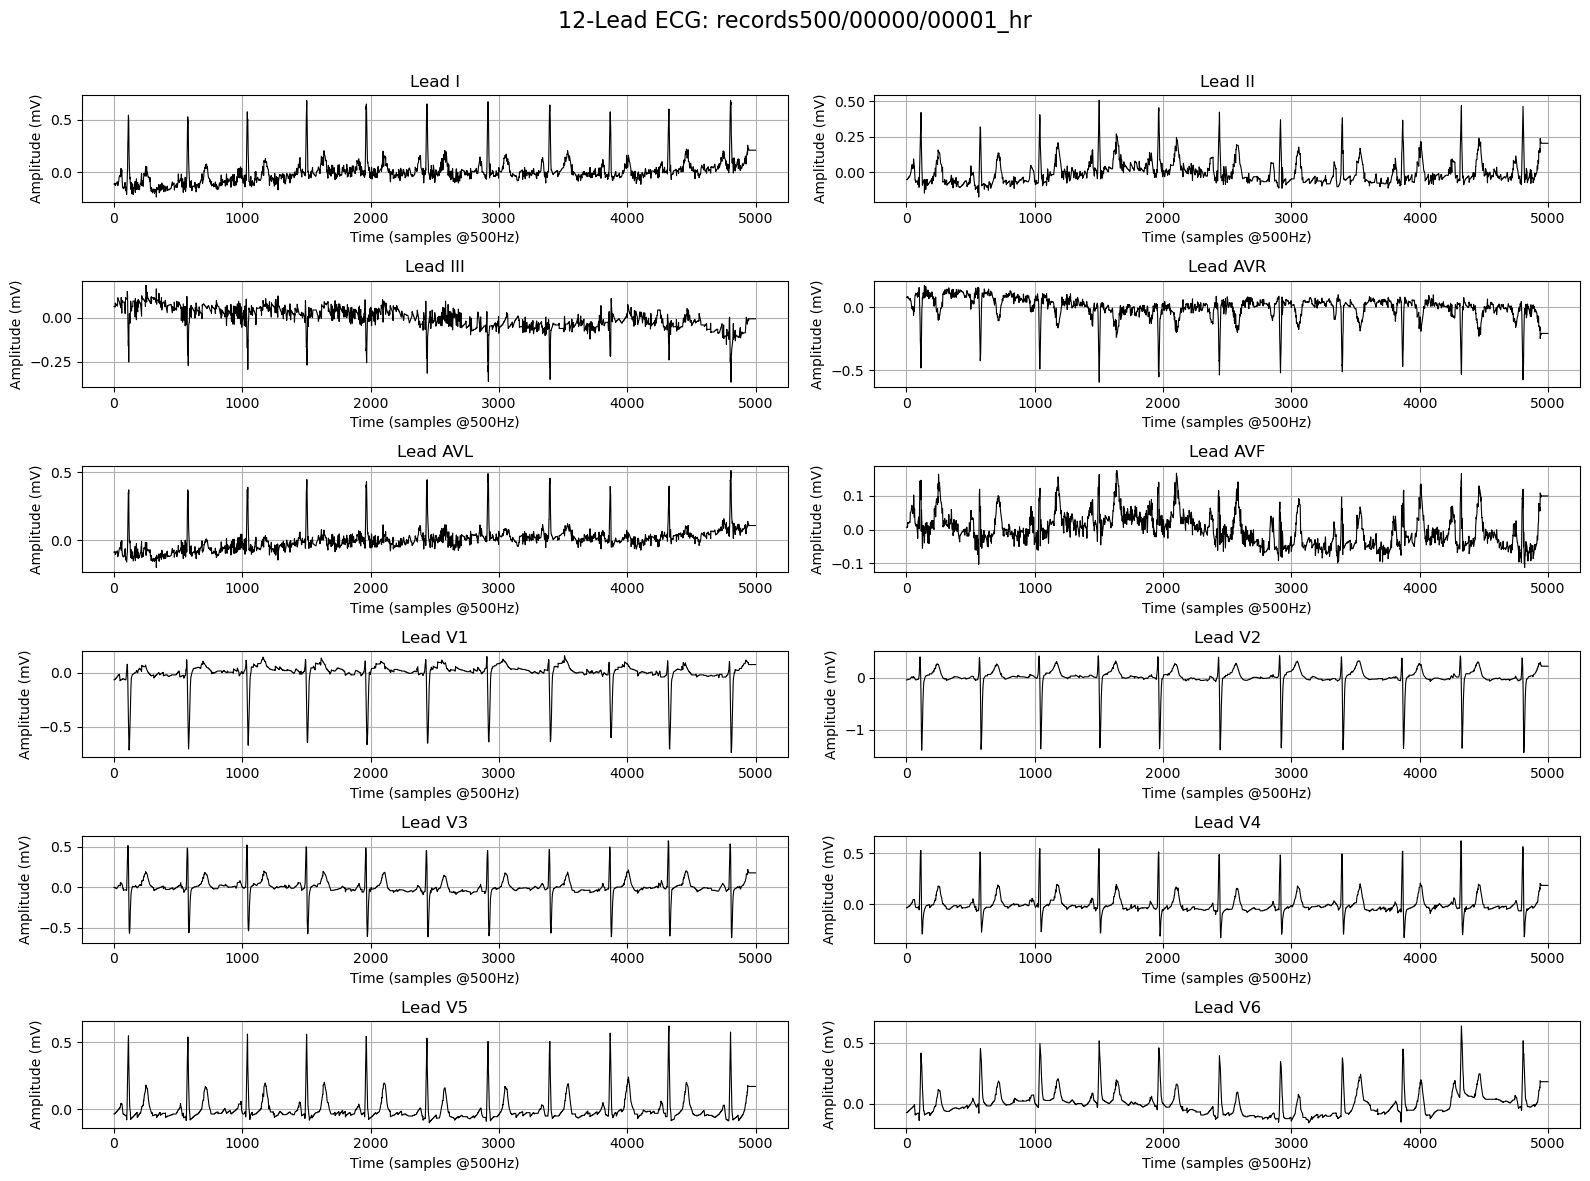

In [24]:
lead_names = record.sig_name

plt.figure(figsize=(16, 12))
for i in range(12):
    plt.subplot(6, 2, i + 1)
    plt.plot(signal[:, i], color='black', linewidth=0.8)
    plt.title(f"Lead {lead_names[i]}")
    plt.xlabel("Time (samples @500Hz)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)

plt.suptitle(f"12-Lead ECG: {sample['filename_hr']}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

The 12-lead ECG provides a multi-angle electrical mapping of the heart.

Lead I views the heart from left to right and focuses on the high lateral wall of the left ventricle. It is useful in detecting lateral ischemia, left atrial enlargement, and also serves as a reliable baseline for overall rhythm analysis.

Lead II provides a diagonal view from the right arm to the left leg and is considered the best lead for rhythm monitoring, P-wave visibility, and detecting inferior wall infarctions. It’s commonly used in hospital monitors and ambulatory ECG devices.

Lead III shares the inferior focus of Lead II but looks at it from a different angle (left arm to left leg). It complements Lead II in confirming inferior myocardial infarctions.

aVR looks from the center of the heart toward the right atrium and upper body. It is typically negative; if it becomes upright, this may indicate lead reversal, ventricular tachycardia, or global ischemia.

aVL targets the high lateral wall of the heart and is helpful for detecting lateral infarctions. Changes in aVL often precede broader lateral involvement in coronary artery disease.

aVF faces downward, viewing the inferior wall directly. Like II and III, it assists in diagnosing inferior infarctions, especially ST segment elevations or depressions.

V1 is positioned at the fourth intercostal space on the right of the sternum. It views the right ventricle and interventricular septum, making it essential for diagnosing right bundle branch block (RBBB), Brugada syndrome, atrial arrhythmias, and ventricular tachycardia.

V2, located on the left side of the sternum, shares the septal view and is commonly used alongside V1 to detect septal infarctions, ST elevation, and conduction abnormalities.

V3 lies between V2 and V4 and transitions the view from septal to anterior. It is especially important in monitoring the evolution of anterior myocardial infarctions and assessing ischemic progression.

V4, placed on the midclavicular line, is one of the most sensitive leads for the anterior wall of the left ventricle. ST elevation here strongly suggests an anterior myocardial infarction, often due to occlusion of the left anterior descending (LAD) artery.

V5 and V6 provide a lateral view of the heart, specifically the left lateral ventricular wall. These leads are excellent for identifying lateral infarctions, left ventricular hypertrophy, and ischemic patterns. V5 often displays large R-waves, and changes here can complement findings in V4 and aVL.